# Plotting of figures

In [1]:
import os
import string

import cartopy
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
# to run the script, change this based on where you saved the data
input_folder = "/gpfs/data/fs71966/amedvedova/publication_data"

# folder to load data from
folder_processed_data = f"{input_folder}/processed_data"

# folder to save the created figures
folder_figures = f"{input_folder}/figures"


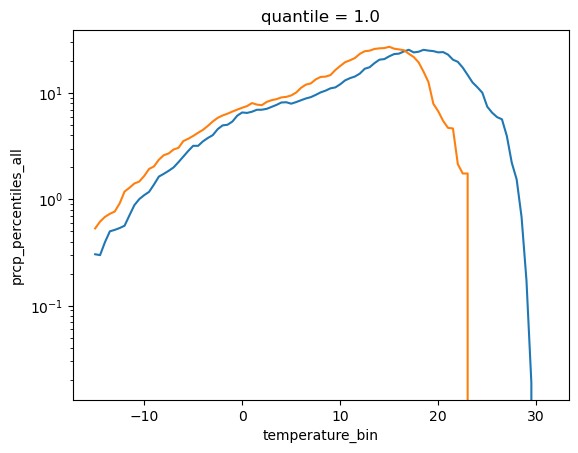

In [8]:
ds_tas = xr.open_dataset("/gpfs/data/fs71966/amedvedova/publication_data/processed_data/quantiles_GeoSphere_eval_hdmean_allseasons.nc")
ds_td = xr.open_dataset("/gpfs/data/fs71966/amedvedova/publication_data/processed_data/quantiles_GeoSphere_eval_hdmean_allseasons_td.nc")

fig, ax = plt.subplots()
ds_tas.prcp_percentiles_all.mean(dim="station_name").isel(quantile=-1).plot(ax=ax)
ds_td.prcp_percentiles_all.mean(dim="station_name").isel(quantile=-1).plot(ax=ax)

ax.set_yscale('log')

# Definitions

## Load data

In [5]:
# statistical requirements

# at least this fraction of stations has to have enough measurements in a temperature bin
req_station_fraction = 0.2
req_model_fraction = 0.2

# daily requirements: at least 100 days per year, or 25 per season. The hourly requirements correspond to that (daily requirements * 24 hours)
req_count_days_year = 100
req_count_days_season = int(req_count_days_year / 4)
req_count_hours_year = req_count_days_year * 24
req_count_hours_season = req_count_days_season * 24

# define a base dictionary, where keys and values are shared among all types of datasets
kwargs_req_base = dict(
    requirements=True,
    req_station_fraction=req_station_fraction,
    req_model_fraction=req_model_fraction
)

# define keys and values specific to individual datasets
# use dictionary unpacking to propagate the base values among all subsequent dictionaries
kwargs_req_quantiles_days_year    = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'count_all'}
kwargs_req_quantiles_hours_year   = {**kwargs_req_base,  'req_count': req_count_hours_year,    'count_var': 'count_all'}
kwargs_req_quantiles_days_season  = {**kwargs_req_base,  'req_count': req_count_days_season,   'count_var': 'count_all'}
kwargs_req_quantiles_hours_season = {**kwargs_req_base,  'req_count': req_count_hours_season,  'count_var': 'count_all'}
kwargs_req_daystats_year          = {**kwargs_req_base,  'req_count': req_count_days_year,     'count_var': 'daily_count'}
kwargs_req_daystats_season        = {**kwargs_req_base,  'req_count': req_count_days_season,   'count_var': 'daily_count'}

In [6]:
# only use bins where there's enough stations and models - set others to nan
def apply_requirements(
    ds,
    count_var="count_all",
    req_count=2400,
    req_station_fraction=0.2,
    req_model_fraction=0.2,
    requirements=True,
):
    """
    We filter the precipitation data according to the following rules:
    1. First, for any given station and model, we exclude temperature bins with fewer than 2400 recorded 
        hours (equivalent to 100 days). Only bins meeting this threshold are retained for further analysis.
    2. Second, we calculate the mean value across all stations that meet the first criterion (i.e., bins with 
        at least 2400 hours). If fewer than 20% of the stations (< 56) have valid data for a given temperature bin, 
        the bin is considered not robust and excluded from further analysis. This is done separately for each model.
    3. Finally, for the model ensembles, we calculate the mean across all models that have valid averages 
        from step 2. If fewer than 20% of the models have valid values for a given temperature bin, the 
        bin is considered invalid

    Args:
        ds (xr.Dataset): any of the processed hourly/daily datasets with statistics as a funcion of temperature.
        count_var (str, optional): Variable with the count of hours/days in a given temperature bin.
            It is used to determine whether the dataset fulfills the count requirements. Defaults to "count_all".
        req_count (int, optional): Used in Step 1: required number of values in each temperature bin
            at each station location and in each model. Bins with fewer valid values than this threshold
            are set to NaN. Defaults to 2400.
        req_station_fraction (float, optional): Used in Step 2: required fraction of stations that have to have 
            enough valid values. Defaults to 0.2.
        req_model_fraction (float, optional): Used in Step 3: required fraction of models that have to have 
            enough valid values at enough stations. Defaults to 0.2.
        requirements (bool, optional): Boolean flag deciding whether the requirements are applied to the input dataset.
            If it is set to false, the original input dataset is returned unchanged. Defaults to True.

    Returns:
        ds_threshold or ds (xr.Dataset): One of:
            ds_threshold: a dataset to which the requirements were applied, with NaNs in bins where the 
                requirements were not met
            ds: the original, unchanged dataset
    """
    
    if requirements is True:
        # Step 1: set bins that don't have the required count of values in them to nan
        ds_threshold = ds.where(ds[count_var] >= req_count, drop=False)

        # Step 2: keep only bins where enough stations have the required amount of values, set others to zero
        # example: for a given model, only 5% of stations exceed the required threshold. even the bins with enough data are set to nan.
        ds_threshold = ds_threshold.where(ds_threshold.notnull().sum(dim='station_name') >= (len(ds_threshold.station_name) * req_station_fraction), drop=False)
        
        # Step 3: keep only bins where enough models have enough data from enough stations
        if 'model' in ds.dims:
            ds_threshold = ds_threshold.where(ds_threshold.notnull().sum(dim='model') >= (len(ds_threshold.model) * req_model_fraction), drop=False)
        return ds_threshold
    
    else:
        return ds

In [7]:
# Load all data into a dictionary: no requirements applied
dict_ds_noreq = {}

# load data for each season and period
for season in ['DJF', 'MAM', 'JJA', 'SON', 'allseasons']:
    dict_ds_noreq[f'ds_quantiles_stations_eval_hdmean_{season}'] = xr.open_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'})
    dict_ds_noreq[f'ds_quantiles_stations_eval_ddmean_{season}'] = xr.open_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'})
    dict_ds_noreq[f'ds_daystats_stations_eval_dmean_{season}'] = xr.open_dataset(f'{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc', engine='h5netcdf')

    for period in ['eval', 'hist', 'rcp']:
        for res in ['kmscale', 'driving']:
            dict_ds_noreq[f'ds_quantiles_{res}_{period}_hdmean_{season}'] = xr.open_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_hdmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'})
            dict_ds_noreq[f'ds_quantiles_{res}_{period}_ddmean_{season}'] = xr.open_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_ddmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'})
            dict_ds_noreq[f'ds_daystats_{res}_{period}_dmean_{season}'] = xr.open_dataset(f'{folder_processed_data}/various_daily_stats_{res}_ensemble_{period}_dmean_{season}.nc', engine='h5netcdf')

In [49]:
dict_ds_noreq[f'ds_quantiles_stations_eval_hdmean_allseasons'].elevation.quantile([0.33,0.66,1])

<xarray.DataArray 'elevation' (quantile: 3)> Size: 24B
array([ 450.  ,  772.16, 2863.9 ])
Coordinates:
  * quantile  (quantile) float64 24B 0.33 0.66 1.0

In [9]:
# Load all data into a dictionary: apply requirements
dict_ds_req = {}

# load data for each season and period
# for season in ['DJF', 'MAM', 'JJA', 'SON',]:
for season in ['DJF',  'JJA', ]:
    dict_ds_req[f'ds_quantiles_stations_eval_hdmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_hours_season)
    dict_ds_req[f'ds_quantiles_stations_eval_ddmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_days_season)
    dict_ds_req[f'ds_daystats_stations_eval_dmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc', engine='h5netcdf'), **kwargs_req_daystats_season)

    for period in ['eval', 'hist', 'rcp']:
        for res in ['kmscale', 'driving']:
            dict_ds_req[f'ds_quantiles_{res}_{period}_hdmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_hdmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_hours_season)
            dict_ds_req[f'ds_quantiles_{res}_{period}_ddmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_ddmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_days_season)
            dict_ds_req[f'ds_daystats_{res}_{period}_dmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/various_daily_stats_{res}_ensemble_{period}_dmean_{season}.nc', engine='h5netcdf'), **kwargs_req_daystats_season)

# the whole year is done separately because we use a different dictionary with requirements
for season in ['allseasons', ]:
    dict_ds_req[f'ds_quantiles_stations_eval_hdmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_hdmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_hours_year)
    dict_ds_req[f'ds_quantiles_stations_eval_ddmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_GeoSphere_eval_ddmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_days_year)
    dict_ds_req[f'ds_daystats_stations_eval_dmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_{season}.nc', engine='h5netcdf'), **kwargs_req_daystats_year)

    for period in ['eval', 'hist', 'rcp']:
        for res in ['kmscale', 'driving']:
            dict_ds_req[f'ds_quantiles_{res}_{period}_hdmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_hdmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_hours_year)
            dict_ds_req[f'ds_quantiles_{res}_{period}_ddmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/quantiles_{res}_ensemble_{period}_ddmean_{season}.nc', engine='h5netcdf').rename({'quantile': 'quantiles'}), **kwargs_req_quantiles_days_year)
            dict_ds_req[f'ds_daystats_{res}_{period}_dmean_{season}'] = apply_requirements(xr.open_dataset(f'{folder_processed_data}/various_daily_stats_{res}_ensemble_{period}_dmean_{season}.nc', engine='h5netcdf'), **kwargs_req_daystats_year)

In [10]:
# open files used for orography plot
# load mean model orographies (km-scale/coarse ensemne means) over the whole region
ds_orog_kmscale = xr.open_dataset(f'{input_folder}/raw_data/orog_ensmean_kmscale_remap3km.nc', engine='h5netcdf')
ds_orog_driving = xr.open_dataset(f'{input_folder}/raw_data/orog_ensmean_driving_remap12km.nc', engine='h5netcdf')
# load some random file (one of the used above) to get information about stations - they're the same across all files
ds_stations = xr.open_dataset(f'{folder_processed_data}/various_daily_stats_GeoSphere_eval_dmean_allseasons.nc', engine='h5netcdf')[['elevation', 'lat', 'lon']]

## Plot and color settings

In [11]:
# define colors
c1_eval = '#333333'
c2_eval = '#686868'
c3_eval = '#959595'
c1_hist = '#105ba4'
c2_hist = '#3787c0'
c3_hist = '#6aaed6'
c1_rcp = '#b11218'
c2_rcp = '#e32f27'
c3_rcp = '#fb694a'

colors_eval = [c3_eval, c2_eval, c1_eval]
colors_hist = [c3_hist, c2_hist, c1_hist]
colors_rcp = [c3_rcp,  c2_rcp,  c1_rcp ]

# Map plots: create a new colormap to avoid the blue colors in terrain
cmap_terrain = plt.get_cmap('terrain')

# Create a new LinearSegmentedColormap from the sampled colors
cmap_terrain_truncated = colors.LinearSegmentedColormap.from_list(
    'terrain_truncated',  # name of the new cmap
    cmap_terrain(np.linspace(0.25, 1, 256)),  # Sample the original colormap between minval and maxval
    )

In [ ]:
# PLOT SETTINGS
# set fontsize for all figures
fontsize = 12
fontsize_small = 8

# set markersize for scatter plots
markersize = 10

params = {
    'mathtext.default': 'regular',
    'figure.dpi': 100,
    'font.size': fontsize,
    'axes.titlesize': fontsize,
    'axes.labelsize': fontsize_small,
    'figure.labelsize': fontsize,
    'xtick.labelsize': fontsize_small,
    'ytick.labelsize': fontsize_small,
    'legend.fontsize': fontsize,
    'legend.title_fontsize': fontsize,
 }    
plt.rcParams.update(params)


# temperature range for all figures
xlim_fullrange = (-15, 34)
xlim_allyear = (-10, 25)
xlim_summer = (-1, 31)

# linestyles for datasets
ls_stations = ":"
ls_kmscale  = "-"
ls_upscale = "-."
ls_driving  = "--"

# visibility of the grid
alpha_grid = 0.1

# extent and projection of GeoAxes
map_subplot_kw = {
    "projection": ccrs.PlateCarree(),
    "xlim": [9, 17.5],
    "ylim": [46, 49.5]
}

# Subplot arguments for the map plots
map_kwargs = {
    'vmin': 0,                      # Min elevation
    'vmax': 3800,                   # Max elevation
    'x': 'lon', 
    'y': 'lat',
    'cmap': cmap_terrain_truncated, # Use custom colormap
    'add_colorbar': False,          # Don't plot cbar for each axes, create a custom one for the axes combined 
    'edgecolors': (0, 0, 0, 0.5),   # Color of the gridcell boxes: black with low alpha
    'linewidth': 0.1,               # Linewidth of the gridcells boxes
    'antialiased': True,            # Improves the gridbox plotting 
}

## Other definitions

In [13]:
# Variables to be shown in the plots separated by daily precipitation sums (Fig. 2)
vars_separated = [
    'pr_range_frequency', 
    'wet_hour_count', 
    'wet_hour_mean_intensity',
    'wet_hour_max_intensity', 
    'pr_onset_time', 
    ]

# Daily precipitation ranges and the corresponding labels to be used in the figures
dict_pr_ranges = {
    '0p1_1p0': '0.1-1 mm/d', 
    '1p0_2p5': '1-2.5 mm/d',  
    '2p5_5p0': '2.5-5 mm/d',  
    '05_10'  : '5-10 mm/d',  
    '10_plus': '10<= mm/d',
}
pr_ranges_keys = list(dict_pr_ranges.keys())

# normalize day count per year to 365. The factor of 2 accounts for overlapping bins (equivalent to dx = 0.5)
#   the number of days/hours per year/season differs. Technically it's not 1/4 per season, but close enough.
normalization_factor_days_year  = 2 * 365
normalization_factor_days_season  = 2 * 365 / 4
normalization_factor_hours_year = 2 * 365 * 24
normalization_factor_hours_season = 2 * 365 * 24 / 4

In [14]:
# line settings to be used in a legend
lw_legend = 2

# Lines used to denote individual datasets
line_stations     = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle=':',  label='Observations')
line_kmscale_eval = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle='-',  label='Km-scale, evaluation')
line_driving_eval = mpl.lines.Line2D([], [], color=c1_eval, lw=lw_legend, linestyle='--', label='Coarse-scale, evaluation')
line_kmscale_hist = mpl.lines.Line2D([], [], color=c1_hist, lw=lw_legend, linestyle='-',  label='Km-scale, historical')
line_driving_hist = mpl.lines.Line2D([], [], color=c1_hist, lw=lw_legend, linestyle='--', label='Coarse-scale, historical')
line_kmscale_rcp  = mpl.lines.Line2D([], [], color=c1_rcp,  lw=lw_legend, linestyle='-',  label='Km-scale, RCP8.5')
line_driving_rcp  = mpl.lines.Line2D([], [], color=c1_rcp,  lw=lw_legend, linestyle='--', label='Coarse-scale, RCP8.5')

# Lines used in legends for all/wet days/hours
l1 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_eval)
l2 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_hist)
l3 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c1_rcp)
l4 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_eval)
l5 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_hist)
l6 = mpl.lines.Line2D([], [], ls='-', lw=lw_legend, color=c3_rcp)

# Turn these into lists for later use as handles in legend
handles_all_datasets = [
        line_kmscale_eval,
        line_driving_eval,
        line_stations,
        line_kmscale_hist,
        line_driving_hist,
        line_kmscale_rcp,
        line_driving_rcp,
    ]

handles_all_noneline = handles_all_datasets.copy()
line_None = mpl.lines.Line2D([], [], color='w', lw=lw_legend, linestyle='-',  label='')
handles_all_noneline.insert(3, line_None)

handles_all_wet_days_hours = [
    (l1, l2, l3), 
    (l4, l5, l6)
    ]

# Figure 1, Figure S3: precipitation statistics, all days

## Functions

In [15]:
def get_mean_temperature(ds):
    """
    Calculate the mean seasonal/yearly temperature of a given dataset: averaged over all stations/models.
    Since we don't do this based on raw timeseries, we have to used a weighted mean of temperature:
    Multiply each temperature by the number of times it occurs, and divide by the total number of events.
    This does not necessarily correspond to the REGIONAL mean seasonal temperature since the station
    locations are nor fully representative of the region.

    Args:
        ds (xr.Dataset): dataset containing the count of days in each temperature bin

    Returns:
        float: mean seasonal/yearly temperature of the dataset.
    """
    # get dimensions of the dataset
    dims = [dim for dim in ['model', 'station_name'] if dim in ds.dims]
    # get mean count in the temperature bin
    # fill nans with zeros to have an equal amount of values along all dimensions
    count_total = ds.count_all.fillna(0).mean(dim=dims)
    # get a mean of temperature weighted by the average count of days in each bin
    T_mean = (count_total * count_total.temperature_bin).sum() / count_total.sum()

    return T_mean

In [17]:
def plot_wet_percentage(ds, ax, ls='-', c='k', label=None):
    """
    Plots the fraction of wet to all days or hours, i.e. the wet day/hour percentage on a specified axis.

    Args:
        ds (xr.Dataset): dataset with the count of both all and wet events. Stored in the "quantiles" files.
        ax (mpl.axes.Axes): axis to plot the lines on.
        ls (str, optional): Linestyle. Defaults to '-'.
        c (str, optional): Line color. Defaults to 'k'.
        label (str, optional): Label of the dataset, used in legends. Defaults to None.
    """

    # percentage of wet days/hours
    wet_ratio_per_bin = ds.count_wet / ds.count_all * 100
    
    # average over certain dimensions: stations for station data, models and stations for model data
    dims = [dim for dim in ['model', 'station_name'] if dim in ds.dims]
    mean_wet_ratio_per_bin = wet_ratio_per_bin.mean(dim=dims, skipna=True)
    mean_wet_ratio_per_bin.plot(ax=ax, color=c, ls=ls, label=label)

    return mean_wet_ratio_per_bin


In [18]:
def decorate_axis(ax, axis_grid='both'):
    """
    Change the tick settings of each subplot and add a grid

    Args:
        ax (mpl.axes.Axes): axis to change the settings of
        axis_grid (str, optional): Which grid lines to draw: either both, or only
        vertical in the CC plot. Defaults to 'both'.
    """
    # set x-axis (temperature) ticks same for all plots
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(base=10))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=5))

    # label all major ticks on both x- and y-axis with small labels
    ax.tick_params(axis='x', labelbottom=True, labelsize=fontsize_small)
    ax.tick_params(axis='y', labelleft=True, labelsize=fontsize_small)
    
    # add grid to all plots
    ax.grid(which='major', axis=axis_grid, lw=1, c='k', ls="-", alpha=alpha_grid)

    return

## Plots

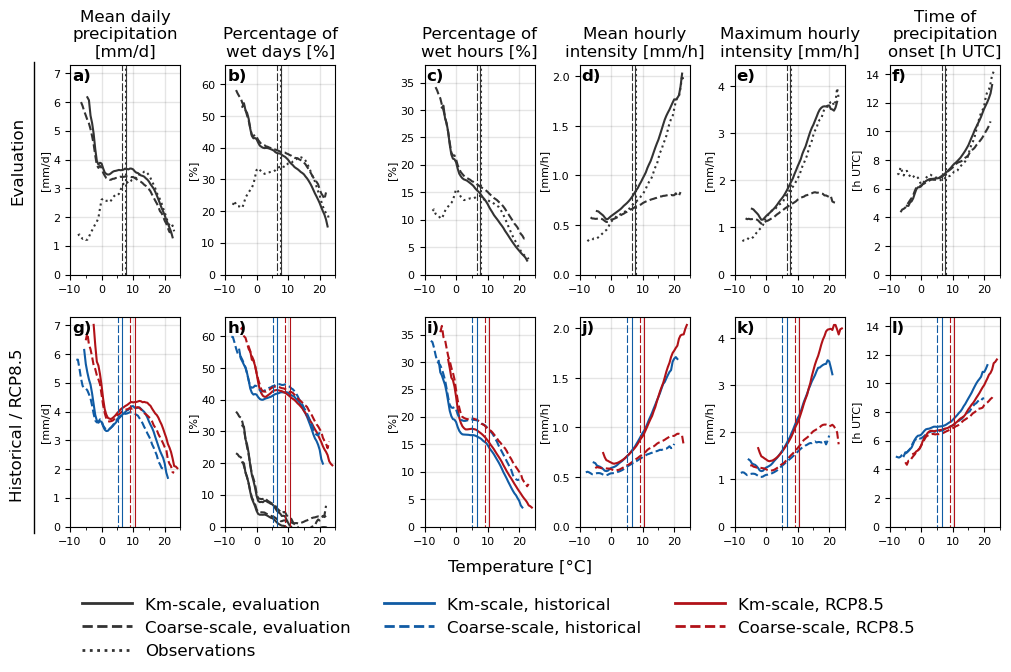

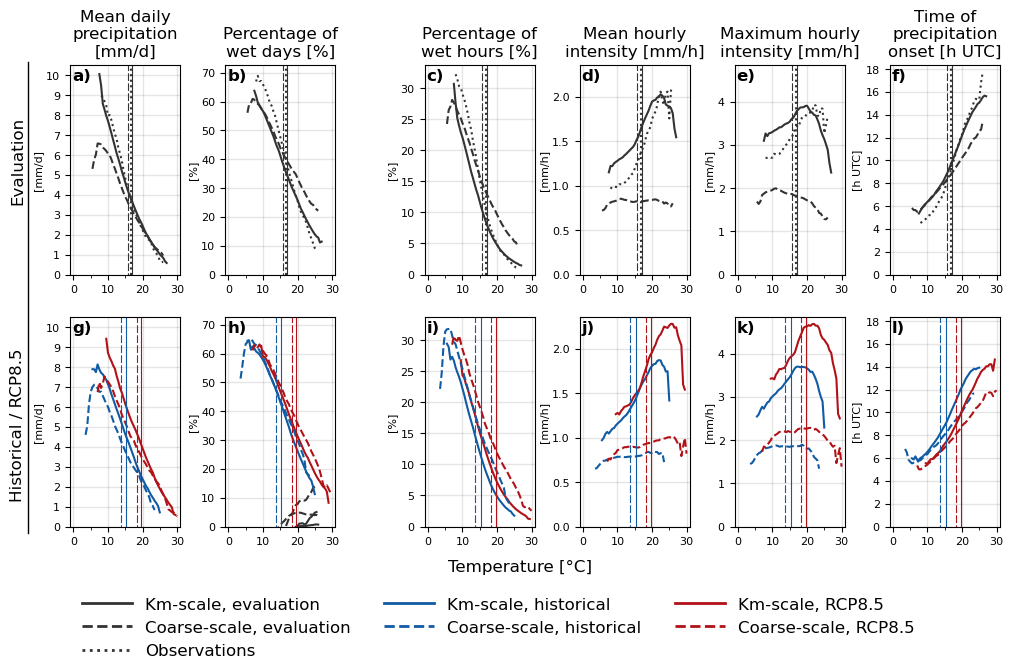

In [ ]:
# Variables to be plotted in Fig. 1 (not complete list)
vars_alldays = [
    "mean_daily_precipitation",
    "wet_hour_mean_intensity_all",
    "wet_hour_max_intensity_all",
    "pr_onset_time_all",
]

# subplot titles for the variables above + others
titles_alldays = [
    "Mean daily\nprecipitation\n[mm/d]",
    "Percentage of\nwet days [%]",
    "Percentage of\nwet hours [%]",
    "Mean hourly\nintensity [mm/h]",
    "Maximum hourly\nintensity [mm/h]",
    "Time of\nprecipitation\nonset [h UTC]",
]

# use gridspec to add whitespace (narrow, empty axis) between the daily and the hourly subplots
ratio = 1
gs = mpl.gridspec.GridSpec(2, 7, width_ratios=[ratio, ratio, 0, ratio, ratio, ratio, ratio], wspace=0.47)

# adjust the position of the vertical line between eval/hist/rcp text and units of the first column
for season, x_position_vline in zip(["allseasons", "JJA"], [0.095, 0.09]):
    # determine requirements based on season/year
    if season == "allseasons":
        kwargs_req_quantiles_days = kwargs_req_quantiles_days_year
        kwargs_req_quantiles_hours = kwargs_req_quantiles_hours_year
        kwargs_req_daystats = kwargs_req_daystats_year
    else:
        kwargs_req_quantiles_days = kwargs_req_quantiles_days_season
        kwargs_req_quantiles_hours = kwargs_req_quantiles_hours_season
        kwargs_req_daystats = kwargs_req_daystats_season

    # initiate figure without axes
    fig = plt.figure(
        figsize=[12, 6]
    )

    # create a placeholder array to hold the axes that will be added to the figure according to the gridspec
    axes = np.empty((2, 6),  dtype=object)
    # we want 2 rows, 6 columns
    for i in range(2):
        for j in range(6): 
            # Skip the empty placeholder axis which is used to create empty space
            actual_col = j if j < 2 else j + 1

            # If we're in the bottom row, share y-axis limits with the axis above
            if i == 0:
                share_ax = None
            else: 
                share_ax = axes[0, j]
            
            # add axis to the figure according to gridspec
            ax = fig.add_subplot(gs[i, actual_col], sharey=share_ax)
            # add the created axis to the axes array
            axes[i, j] = ax

    # now that axes are created, start plotting
    # FIRST ROW: evaluation
    # 2nd + 3rd column: percentage of wet days and wet hours
    # TODO now I plot the change at the level of lines, not averaged over individual models
    wet_percentage_lines_eval = {}
    for res, ls in zip(["stations", "kmscale", "driving"], [ls_stations, ls_kmscale, ls_driving]):
        wet_percentage_lines_eval[f"{res}_daily"] = plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_eval_ddmean_{season}"], axes[0, 1], ls=ls, c=c1_eval)
        wet_percentage_lines_eval[f"{res}_hourly"] = plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_eval_hdmean_{season}"], axes[0, 2], ls=ls, c=c1_eval)

    # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
    for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
        dict_ds_req[f"ds_daystats_stations_eval_dmean_{season}"][v].mean(dim="station_name").plot(ax=axes[0, i], ls=ls_stations, color=c1_eval)
        dict_ds_req[f"ds_daystats_kmscale_eval_dmean_{season}"][v].mean(dim=["station_name", "model"]).plot(ax=axes[0, i], ls=ls_kmscale, color=c1_eval)
        dict_ds_req[f"ds_daystats_driving_eval_dmean_{season}"][v].mean(dim=["station_name", "model"]).plot(ax=axes[0, i], ls=ls_driving, color=c1_eval)

    # SECOND ROW: hist + rcp
    # 2nd + 3rd column: percentage of wet days and wet hours
    wet_percentage_lines_change = {}
    for res, ls in zip(["kmscale", "driving"], [ls_kmscale, ls_driving]):
        wet_percentage_lines_eval[f"{res}_hist_daily"] = plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_hist_ddmean_{season}"], axes[1, 1], ls=ls, c=c1_hist)
        wet_percentage_lines_eval[f"{res}_hist_hourly"] = plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_hist_hdmean_{season}"], axes[1, 2], ls=ls, c=c1_hist)
        wet_percentage_lines_eval[f"{res}_rcp_daily"] = plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_rcp_ddmean_{season}"], axes[1, 1], ls=ls, c=c1_rcp)
        wet_percentage_lines_eval[f"{res}_rcp_hourly"] = plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_rcp_hdmean_{season}"], axes[1, 2], ls=ls, c=c1_rcp)

    # for res, ls in zip(["kmscale", "driving"], [ls_kmscale, ls_driving]):
    #     (wet_percentage_lines_eval[f"{res}_daily"] - wet_percentage_lines_eval["stations_daily"]).plot(ax=axes[1, 1], ls=ls, c=c1_eval)
    #     (wet_percentage_lines_eval[f"{res}_hourly"] - wet_percentage_lines_eval["stations_hourly"]).plot(ax=axes[1, 1], ls=ls, c=c1_eval)

    # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
    for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
        dict_ds_req[f"ds_daystats_kmscale_hist_dmean_{season}"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_kmscale, color=c1_hist)
        dict_ds_req[f"ds_daystats_driving_hist_dmean_{season}"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_driving, color=c1_hist)
        dict_ds_req[f"ds_daystats_kmscale_rcp_dmean_{season}"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_kmscale, color=c1_rcp)
        dict_ds_req[f"ds_daystats_driving_rcp_dmean_{season}"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_driving, color=c1_rcp)

    # Change axes settings: ranges, ticks, labels, etc
    for ax in axes.flatten():
        ax.set_ylim(0, None)
        if season == "JJA":
            ax.set_xlim(xlim_summer)
        else:
            ax.set_xlim(xlim_allyear)
        ax.set_xlabel("")
        decorate_axis(ax)

    # set titles, x- and y-labels of the columns: others are set before
    for ax, title in zip(axes[0, :], titles_alldays):
        ax.set_title(title) 

    unit_labels = ['[mm/d]', '[%]', '[%]', '[mm/h]', '[mm/h]', '[h UTC]']
    major_ticks = [1, 10, 5, 0.5, 1, 2]
    labelpad = 2.3
    for ax_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks)):
        for ax in axes[:, ax_idx]:
            # add units to each y-axis
            ax.set_ylabel(unit, labelpad=labelpad)
            # determine major y-ticks for every subplot
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))

    # add text to the first column to add Evaluation/Historical/RCP8.5
    x=0.075
    fig.text(x, 0.72, 'Evaluation', rotation=90, fontsize=fontsize, va='center')
    fig.text(x, 0.28, 'Historical / RCP8.5', rotation=90, fontsize=fontsize, va='center')

    fig.supxlabel("Temperature [°C]", y=0.03)

    # add vertical line in the left side of the plot
    x = x_position_vline
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                  color='k', linestyle='-', linewidth=1))

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
        ax.text(0.02, 0.98, f"{letter})", transform=ax.transAxes,
        fontweight="bold", va="top")

    # add mean temperature info: vertical line in the corresponding style for all datasets
    longdash = (5, (7, 2))
    for ax in axes[0, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_stations_eval_ddmean_{season}"]), color=c1_eval, lw=1.5, ls=":")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_eval_ddmean_{season}"]), color=c1_eval, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_eval_ddmean_{season}"]), color=c1_eval, lw=0.8, ls=longdash)        
        
    for ax in axes[1, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_hist_ddmean_{season}"]), color=c1_hist, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_hist_ddmean_{season}"]), color=c1_hist, lw=0.8, ls=longdash)        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_kmscale_rcp_ddmean_{season}"]), color=c1_rcp, lw=0.8, ls="-")
        ax.axvline(x=get_mean_temperature(dict_ds_noreq[f"ds_quantiles_driving_rcp_ddmean_{season}"]), color=c1_rcp, lw=0.8, ls=longdash)

    # legend
    axes[1, 0].legend(
        handles=handles_all_datasets,
        bbox_to_anchor=[0, -0.28],
        borderpad=0.2,
        ncol=3,
        handlelength=3,
        frameon=False,
        loc="upper left")


# Figure 2, Figure S4: precipitation statistics separated by daily precipitation sums

## Functions and definitions

In [20]:
def plot_pr_range_percentage(ds, dims, r, ax, ls, color, lw=None, alpha=1, label=None):
    """
    Plot the percentage of days at each temperature that fall within each given precipitation range
    (0.1-1, 1-2.5, 2.5-5, 5-10, 10+ mm/d). The lowest category does not constitue a wet day.
    The sum of the other 4 categories adds up to the percentage of all wet days seen in Fig 1.

    Args:
        ds (xr.Dataset): Dataset with the precipitation statistics separated my total daily preicpitation
            sums. In this notebook it's the "various daily stats" files.
        dims (list): Dimensions to take the sums over.
        r (str): string determining the daily precipitation range, one of:
            '0p1_1p0', '1p0_2p5', '2p5_5p0', '05_10', '10_plus'  
        ax (mpl.axes.Axes): axis to plot the lines on.
        ls (str): Linestyle.
        color (str): Color of the plotted line.
        lw (int/float, optional): Linewidth of the plotted line. Defaults to None.
        alpha (float, optional): Transparency of the plotted line. Defaults to 1.
        label (str, optional): Label of the dataset, used in legends. Defaults to None.
    """

    # plot the percentage of days within the range on the selected axis
    (100 * ds[f'pr_range_count_{r}'].sum(dim=dims) / ds['daily_count'].sum(dim=dims)).plot(ax=ax, ls=ls, lw=lw, c=color, alpha=alpha, label=label)
    return


def plot_wet_hour_freq(ds, dims, var_full, ax, ls, color, lw=None, alpha=1):
    """
    Plot the percentage of wet hours on days with a given daily precipitation range.

    Args:
        ds (xr.Dataset): Dataset with the precipitation statistics separated my total daily preicpitation
            sums. In this notebook it's the "various daily stats" files.
        dims (list): Dimensions to take the average over.
        var_full (str): Variable to plot of the form 'wet_hour_count_Range', where Range is one of:
            '0p1_1p0', '1p0_2p5', '2p5_5p0', '05_10', '10_plus'
        ax (mpl.axes.Axes): axis to plot the lines on.
        ls (str): Linestyle.
        color (str): Color of the plotted line.
        lw (int/float, optional): Linewidth of the plotted line. Defaults to None.
        alpha (float, optional): Transparency of the plotted line. Defaults to 1.
    """
    (ds[var_full].mean(dim=dims) / 24 * 100).plot(ax=ax, ls=ls, lw=lw, c=color, alpha=alpha) 
    return     

In [21]:
# datasets without requirements
ds_stations_eval_noreq = dict_ds_noreq['ds_daystats_stations_eval_dmean_allseasons']
ds_kmscale_eval_noreq = dict_ds_noreq['ds_daystats_kmscale_eval_dmean_allseasons']
ds_driving_eval_noreq = dict_ds_noreq['ds_daystats_driving_eval_dmean_allseasons']

ds_kmscale_hist_noreq = dict_ds_noreq['ds_daystats_kmscale_hist_dmean_allseasons']
ds_driving_hist_noreq = dict_ds_noreq['ds_daystats_driving_hist_dmean_allseasons']

ds_kmscale_rcp_noreq = dict_ds_noreq['ds_daystats_kmscale_rcp_dmean_allseasons']
ds_driving_rcp_noreq = dict_ds_noreq['ds_daystats_driving_rcp_dmean_allseasons']

# apply requirements to all datasets
ds_stations_eval_req = dict_ds_req['ds_daystats_stations_eval_dmean_allseasons']
ds_kmscale_eval_req = dict_ds_req['ds_daystats_kmscale_eval_dmean_allseasons']
ds_driving_eval_req = dict_ds_req['ds_daystats_driving_eval_dmean_allseasons']

ds_kmscale_hist_req = dict_ds_req['ds_daystats_kmscale_hist_dmean_allseasons']
ds_driving_hist_req = dict_ds_req['ds_daystats_driving_hist_dmean_allseasons']

ds_kmscale_rcp_req = dict_ds_req['ds_daystats_kmscale_rcp_dmean_allseasons']
ds_driving_rcp_req = dict_ds_req['ds_daystats_driving_rcp_dmean_allseasons']

# Figure 3: CC Scaling

## Functions

In [28]:
def add_CC_lines(ax, t_bins, CC_alpha=alpha_grid, lw=1):
    """
    Add thin lines to guide the eye to each subplot: at 7%/K and 14%/K increase.

    Args:
        ax (mpl.axes.Axes): axis to plot the lines on.
        t_bins (xr.DataArray): Temperature bins, used as the x-axis coordinate
        CC_alpha (float, optional): Transparency of the lines. Defaults to 0.5.
        lw (float, optional): Linewidth of the lines. Defaults to 0.5.
    """
    # CC scaling axes: add 7% and 14% increase lines
    x0 = t_bins[0]
    x1 = t_bins[-1]

    for y in [0.25, 0.5, 1, 2, 4, 8]:
        ax.plot([x0, x1], [y, y*1.07**(x1-x0)], color='k', ls=(5, (10, 3)), lw=lw, alpha=CC_alpha)
    # only add 14% increase lines if this is True, don't plot otherwise
    for y in [0.125, 0.25, 0.5, 1, 2, 4]:
        ax.plot([x0, x1], [y, y*1.14**(x1-x0)], color='k', ls='-.', lw=lw, alpha=CC_alpha)
    
    return

# Spread over models


In [39]:
def plot_wet_percentage_individual(ds, ax, ls='-', c='k', label=None, lw=1, alpha=1):
    """
    Plots the fraction of wet to all days or hours, i.e. the wet day/hour percentage on a specified axis.

    Args:
        ds (xr.Dataset): dataset with the count of both all and wet events. Stored in the "quantiles" files.
        ax (mpl.axes.Axes): axis to plot the lines on.
        ls (str, optional): Linestyle. Defaults to '-'.
        c (str, optional): Line color. Defaults to 'k'.
        label (str, optional): Label of the dataset, used in legends. Defaults to None.
    """

    # percentage of wet days/hours
    wet_ratio_per_bin = ds.count_wet / ds.count_all * 100
    
    # average over certain dimensions: stations for station data, models and stations for model data
    dims = [dim for dim in ['model', 'station_name'] if dim in ds.dims]
    wet_ratio_per_bin.mean(dim=dims, skipna=True).plot(ax=ax, color=c, ls=ls, label=label, lw=lw, alpha=alpha)

    return


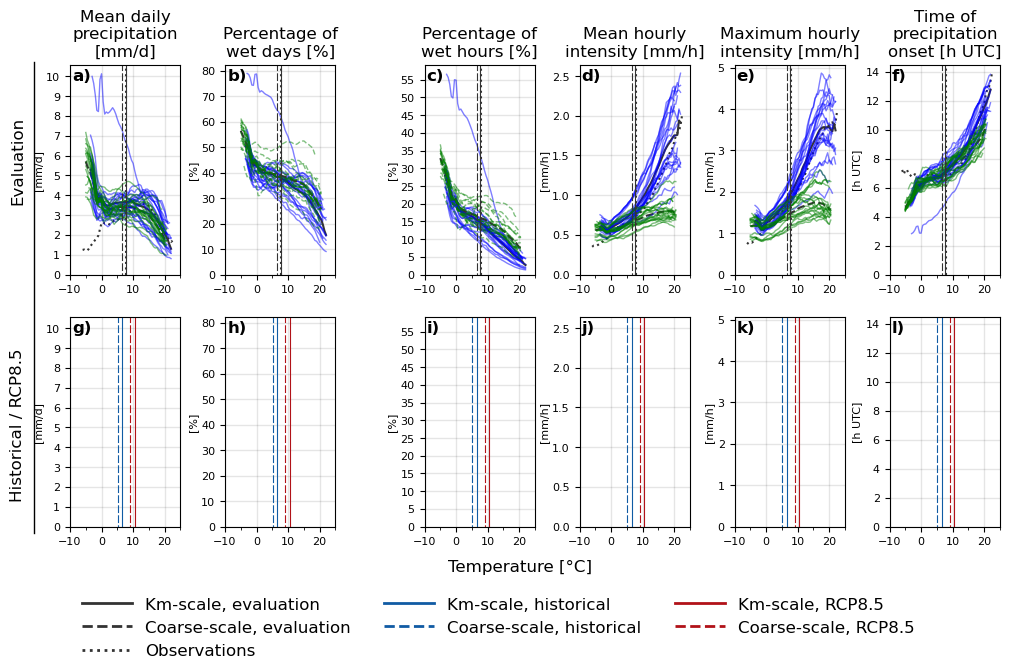

In [40]:
# Variables to be plotted in Fig. 1 (not complete list)
vars_alldays = [
    "mean_daily_precipitation",
    "wet_hour_mean_intensity_all",
    "wet_hour_max_intensity_all",
    "pr_onset_time_all",
]

# subplot titles for the variables above + others
titles_alldays = [
    "Mean daily\nprecipitation\n[mm/d]",
    "Percentage of\nwet days [%]",
    "Percentage of\nwet hours [%]",
    "Mean hourly\nintensity [mm/h]",
    "Maximum hourly\nintensity [mm/h]",
    "Time of\nprecipitation\nonset [h UTC]",
]

models_kmscale = dict_ds_req["ds_daystats_kmscale_eval_dmean_allseasons"].model
models_driving = dict_ds_req["ds_daystats_driving_eval_dmean_allseasons"].model

# use gridspec to add whitespace (narrow, empty axis) between the daily and the hourly subplots
ratio = 1
gs = mpl.gridspec.GridSpec(2, 7, width_ratios=[ratio, ratio, 0, ratio, ratio, ratio, ratio], wspace=0.47)

# adjust the position of the vertical line between eval/hist/rcp text and units of the first column
for season, x_position_vline in zip(["allseasons", ], [0.095, ]):
    # initiate figure without axes
    fig = plt.figure(
        figsize=[12, 6]
    )

    # create a placeholder array to hold the axes that will be added to the figure according to the gridspec
    axes = np.empty((2, 6),  dtype=object)
    # we want 2 rows, 6 columns
    for i in range(2):
        for j in range(6): 
            # Skip the empty placeholder axis which is used to create empty space
            actual_col = j if j < 2 else j + 1

            # If we're in the bottom row, share y-axis limits with the axis above
            if i == 0:
                share_ax = None
            else: 
                share_ax = axes[0, j]
            
            # add axis to the figure according to gridspec
            ax = fig.add_subplot(gs[i, actual_col], sharey=share_ax)
            # add the created axis to the axes array
            axes[i, j] = ax

    # now that axes are created, start plotting
    # FIRST ROW: evaluation
    # 2nd + 3rd column: percentage of wet days and wet hours
    for res, ls, color in zip(["kmscale", "driving"], [ls_kmscale, ls_driving], ['b', 'g']):
        plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_eval_ddmean_allseasons"], axes[0, 1], ls=ls, c=c1_eval)
        plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_eval_hdmean_allseasons"], axes[0, 2], ls=ls, c=c1_eval)
        
        if 'model' in dict_ds_req[f"ds_quantiles_{res}_eval_ddmean_allseasons"].dims:
            for model in dict_ds_req[f"ds_quantiles_{res}_eval_ddmean_allseasons"].model:
                plot_wet_percentage_individual(dict_ds_req[f"ds_quantiles_{res}_eval_ddmean_allseasons"].sel(model=model), axes[0, 1], ls=ls, c=color, lw=1, alpha=0.5)
                plot_wet_percentage_individual(dict_ds_req[f"ds_quantiles_{res}_eval_hdmean_allseasons"].sel(model=model), axes[0, 2], ls=ls, c=color, lw=1, alpha=0.5)

    
    # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
    for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
        dict_ds_req["ds_daystats_stations_eval_dmean_allseasons"][v].mean(dim="station_name").plot(ax=axes[0, i], ls=ls_stations, color=c1_eval)
        dict_ds_req["ds_daystats_kmscale_eval_dmean_allseasons"][v].mean(dim=["station_name", "model"]).plot(ax=axes[0, i], ls=ls_kmscale, color=c1_eval)
        dict_ds_req["ds_daystats_driving_eval_dmean_allseasons"][v].mean(dim=["station_name", "model"]).plot(ax=axes[0, i], ls=ls_driving, color=c1_eval)

        for model in dict_ds_req["ds_daystats_kmscale_eval_dmean_allseasons"].model:
            dict_ds_req["ds_daystats_kmscale_eval_dmean_allseasons"][v].sel(model=model).mean(dim="station_name").plot(ax=axes[0, i], ls=ls_kmscale, color='blue', lw=1, alpha=0.5)

        for model in dict_ds_req["ds_daystats_driving_eval_dmean_allseasons"].model:
            dict_ds_req["ds_daystats_driving_eval_dmean_allseasons"][v].sel(model=model).mean(dim="station_name").plot(ax=axes[0, i], ls=ls_kmscale, color='green', lw=1, alpha=0.5)
    # # SECOND ROW: hist + rcp
    # # 2nd + 3rd column: percentage of wet days and wet hours
    # for res, ls in zip(["kmscale", "driving"], [ls_kmscale, ls_driving]):
    #     plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_hist_ddmean_allseasons"], axes[1, 1], ls=ls, c=c1_hist)
    #     plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_hist_hdmean_allseasons"], axes[1, 2], ls=ls, c=c1_hist)
    #     plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_rcp_ddmean_allseasons"], axes[1, 1], ls=ls, c=c1_rcp)
    #     plot_wet_percentage(dict_ds_req[f"ds_quantiles_{res}_rcp_hdmean_allseasons"], axes[1, 2], ls=ls, c=c1_rcp)

    # # Columns 1, 4, 5, 6: mean daily precipitation, mean daily intensity, max daily intensity, time of precipitation onset
    # for (v, i) in zip(vars_alldays, [0, 3, 4, 5]):
    #     dict_ds_req[f"ds_daystats_kmscale_hist_dmean_allseasons"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_kmscale, color=c1_hist)
    #     dict_ds_req[f"ds_daystats_driving_hist_dmean_allseasons"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_driving, color=c1_hist)
    #     dict_ds_req[f"ds_daystats_kmscale_rcp_dmean_allseasons"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_kmscale, color=c1_rcp)
    #     dict_ds_req[f"ds_daystats_driving_rcp_dmean_allseasons"][v].mean(dim=["station_name", "model"]).plot(ax=axes[1, i], ls=ls_driving, color=c1_rcp)

    # Change axes settings: ranges, ticks, labels, etc
    for ax in axes.flatten():
        ax.set_ylim(0, None)
        if season == "JJA":
            ax.set_xlim(xlim_summer)
        else:
            ax.set_xlim(xlim_allyear)
        ax.set_xlabel("")
        decorate_axis(ax)

    # set titles, x- and y-labels of the columns: others are set before
    for ax, title in zip(axes[0, :], titles_alldays):
        ax.set_title(title) 

    unit_labels = ['[mm/d]', '[%]', '[%]', '[mm/h]', '[mm/h]', '[h UTC]']
    major_ticks = [1, 10, 5, 0.5, 1, 2]
    labelpad = 2.3
    for ax_idx, (unit, tick) in enumerate(zip(unit_labels, major_ticks)):
        for ax in axes[:, ax_idx]:
            # add units to each y-axis
            ax.set_ylabel(unit, labelpad=labelpad)
            # determine major y-ticks for every subplot
            ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=tick))

    # add text to the first column to add Evaluation/Historical/RCP8.5
    x=0.075
    fig.text(x, 0.72, 'Evaluation', rotation=90, fontsize=fontsize, va='center')
    fig.text(x, 0.28, 'Historical / RCP8.5', rotation=90, fontsize=fontsize, va='center')

    fig.supxlabel("Temperature [°C]", y=0.03)

    # add vertical line in the left side of the plot
    x = x_position_vline
    fig.add_artist(plt.Line2D([x, x], [0.1, 0.885], transform=fig.transFigure,
                  color='k', linestyle='-', linewidth=1))

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase):
        ax.text(0.02, 0.98, f"{letter})", transform=ax.transAxes,
        fontweight="bold", va="top")

    # add mean temperature info: vertical line in the corresponding style for all datasets
    longdash = (5, (7, 2))
    for ax in axes[0, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq["ds_quantiles_stations_eval_ddmean_allseasons"]), color=c1_eval, lw=1.5, ls=":")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq["ds_quantiles_kmscale_eval_ddmean_allseasons"]), color=c1_eval, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq["ds_quantiles_driving_eval_ddmean_allseasons"]), color=c1_eval, lw=0.8, ls=longdash)        
        
    for ax in axes[1, :]:
        ax.axvline(x=get_mean_temperature(dict_ds_noreq["ds_quantiles_kmscale_hist_ddmean_allseasons"]), color=c1_hist, lw=0.8, ls="-")        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq["ds_quantiles_driving_hist_ddmean_allseasons"]), color=c1_hist, lw=0.8, ls=longdash)        
        ax.axvline(x=get_mean_temperature(dict_ds_noreq["ds_quantiles_kmscale_rcp_ddmean_allseasons"]), color=c1_rcp, lw=0.8, ls="-")
        ax.axvline(x=get_mean_temperature(dict_ds_noreq["ds_quantiles_driving_rcp_ddmean_allseasons"]), color=c1_rcp, lw=0.8, ls=longdash)

    # legend
    axes[1, 0].legend(
        handles=handles_all_datasets,
        bbox_to_anchor=[0, -0.28],
        borderpad=0.2,
        ncol=3,
        handlelength=3,
        frameon=False,
        loc="upper left")

 

# Experimental

## Elevation dependence

<>:70: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:71: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:72: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:73: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:74: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:70: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:71: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences wil

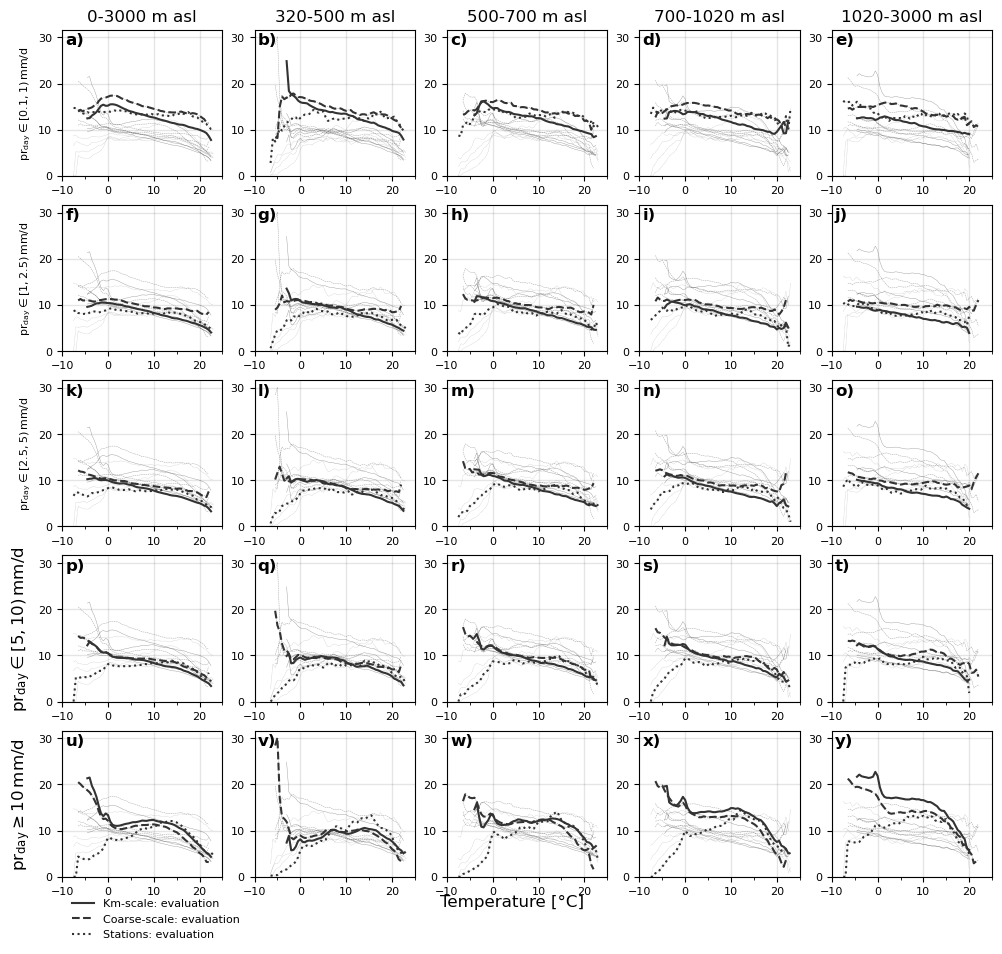

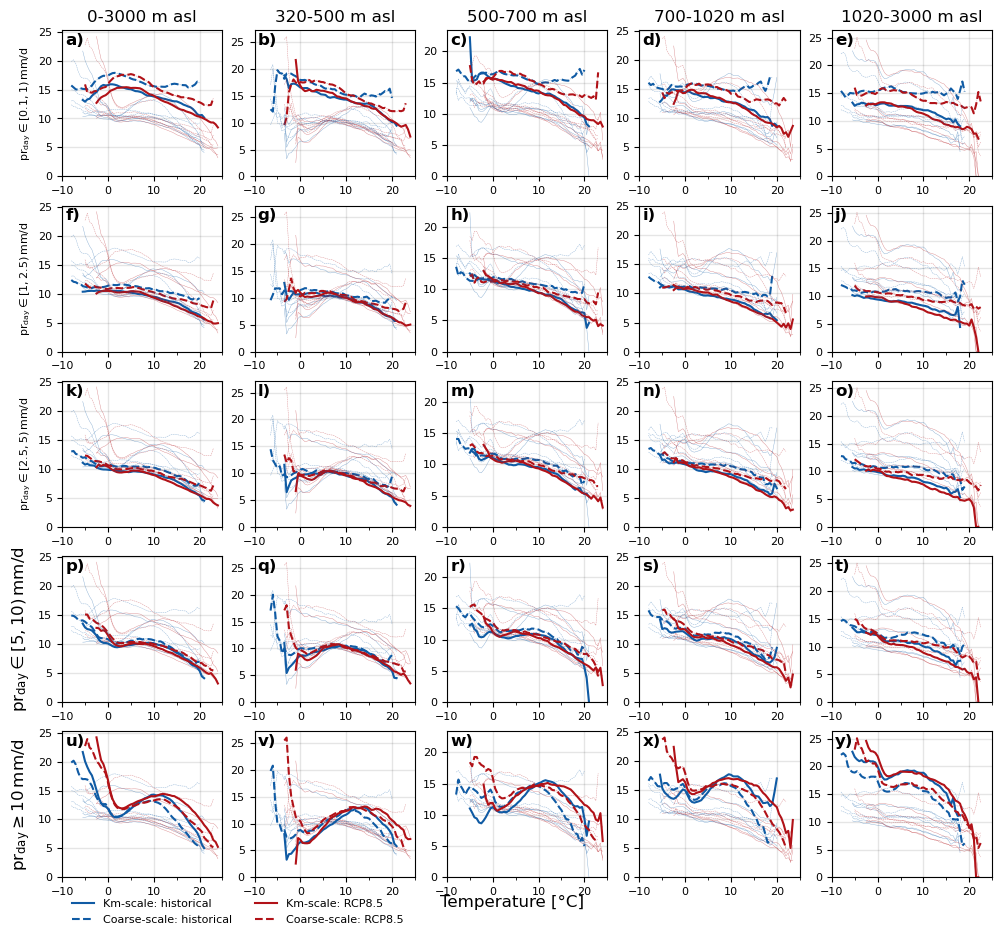

In [45]:
fig_eval, axes_eval = plt.subplots(
    nrows=len(dict_pr_ranges),
    ncols=len(vars_separated),
    sharey=True,
    sharex=True,
    figsize=[12, 11]
)

fig_histrcp, axes_histrcp = plt.subplots(
    nrows=len(dict_pr_ranges),
    ncols=len(vars_separated),
    sharey='col',
    sharex=True,
    figsize=[12, 11]
)

alpha = 0.5
lw_thin = 0.3
plot_thin_lines = True

elevs = [
    (0, 3000),
    (320, 500),
    (500, 700),
    (700, 1020),
    (1020, 3000),
]

# create tuples with axes for each dataset in them and other relevant data for the plot specific to each dataset
datasets = [
    (ds_kmscale_eval_req,  ls_kmscale,  c1_eval, c2_eval, c3_eval, axes_eval,    'Km-scale: evaluation'),
    (ds_driving_eval_req,  ls_driving,  c1_eval, c2_eval, c3_eval, axes_eval,    'Coarse-scale: evaluation'),
    (ds_stations_eval_req, ls_stations, c1_eval, c2_eval, c3_eval, axes_eval,    'Stations: evaluation'),
    (ds_kmscale_hist_req,  ls_kmscale,  c1_hist, c2_hist, c3_hist, axes_histrcp, 'Km-scale: historical'),
    (ds_driving_hist_req,  ls_driving,  c1_hist, c2_hist, c3_hist, axes_histrcp, 'Coarse-scale: historical'),
    (ds_kmscale_rcp_req,   ls_kmscale,  c1_rcp,  c2_rcp,  c3_rcp,  axes_histrcp, 'Km-scale: RCP8.5'),
    (ds_driving_rcp_req,   ls_driving,  c1_rcp,  c2_rcp,  c3_rcp,  axes_histrcp, 'Coarse-scale: RCP8.5'),
    ]

for r_idx, (r, r_label) in enumerate(zip(dict_pr_ranges.keys(), dict_pr_ranges.values())):
    for elev_idx, (elev_min, elev_max) in enumerate(elevs):
        # loop through elevation ranges!
        var_full = f'pr_range_frequency_{r}'
        for (ds, ls, c_primary, c_daily, c_hourly, axes, label) in datasets:
            dims = [dim for dim in ['model', 'station_name'] if dim in ds.dims]
            ds_range = ds.where((ds.elevation >= elev_min) & (ds.elevation < elev_max))

            # plot the percentage of wet days
            plot_pr_range_percentage(ds_range, dims, r, axes[r_idx, elev_idx], ls, c_primary, label=label)

            if plot_thin_lines:
                for ax in axes[:, elev_idx]:
                    plot_pr_range_percentage(ds_range, dims, r, ax, ls, c_primary, lw=lw_thin, alpha=alpha)

            axes[0, elev_idx].set_title(f'{elev_min}-{elev_max} m asl')

# axes settings etc of both figures
for axes in [axes_eval, axes_histrcp]:
    for ax in axes.flatten():
        ax.set_xlim(xlim_allyear)
        ax.set_ylim(0, None)
        ax.set_xlabel('')   
        ax.set_ylabel('')
        decorate_axis(ax)

    # for ax, var in zip(axes[0, :].flatten(), vars_separated):
    #     ax.set_title(var.capitalize().replace('_', ' ').replace(' h ', ' hour '))

    # set labels for both figures
    axes[0, 0].set_ylabel('$pr_{day} \in [0.1, 1)\,mm/d$')
    axes[1, 0].set_ylabel('$pr_{day} \in [1, 2.5)\,mm/d$')
    axes[2, 0].set_ylabel('$pr_{day} \in [2.5, 5)\,mm/d$')
    axes[3, 0].set_ylabel('$pr_{day} \in [5, 10)\,mm/d$',  fontsize=fontsize)
    axes[4, 0].set_ylabel('$pr_{day} \geq 10\,mm/d$',      fontsize=fontsize)

    # axes[0, 0].set_title('Percentage of days with\n$pr_{day} \in range$ [%]',              fontsize=fontsize)

    # add subplot labels: letters in the upper left corner
    for ax, letter in zip(axes.flatten(), string.ascii_lowercase+string.ascii_uppercase):
        ax.text(0.02, 0.98, f'{letter})', transform=ax.transAxes,
        fontweight='bold', va='top')

# add legend: different number of columns for the two figures
axes_eval[-1, 0].legend(frameon=False,    loc='upper left', bbox_to_anchor=[0, -0.08], fontsize=fontsize_small, ncols=1)
axes_histrcp[-1, 0].legend(frameon=False, loc='upper left', bbox_to_anchor=[0, -0.08], fontsize=fontsize_small, ncols=2)

for fig in [fig_eval, fig_histrcp]:
    fig.supxlabel("Temperature [°C]",    y=0.08)
